In [1]:
%pip install -q -U ultralytics roboflow python-dotenv


Note: you may need to restart the kernel to use updated packages.


In [2]:
from roboflow import Roboflow
from dotenv import load_dotenv
import os
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# apikeys.env NO debe subirse a git ni compartirse: agrega la carpeta/archivo a .gitignore.
# Crea tu propio apikeys.env junto al notebook con una linea:
#   ROBOFLOW_API_KEY=tu_api_key_aqui
load_dotenv("apikeys.env")

api_key = os.getenv("ROBOFLOW_API_KEY")
if not api_key:
    raise RuntimeError(
        "No se encontro ROBOFLOW_API_KEY. Crea un archivo apikeys.env junto a este "
        "notebook con la linea: ROBOFLOW_API_KEY=tu_api_key_aqui"
    )

In [3]:
rf = Roboflow(api_key=api_key)
project = rf.workspace("semilleroml").project("sitesafety-pbakq")
dataset = project.version(1).download("yolo26")

print(f"Dataset descargado en: {dataset.location}")

loading Roboflow workspace...


loading Roboflow project...


Extracting Dataset Version Zip to SiteSafety-1 in yolo26::   0%|          | 0/23 [00:00<?, ?it/s]

Extracting Dataset Version Zip to SiteSafety-1 in yolo26:: 100%|██████████| 23/23 [00:00<00:00, 304.72it/s]

Dataset descargado en: C:\Users\jhonp\Documents\GitHub\Trabajos_IA\Talleres\lecture8\yolo\SiteSafety-1


In [4]:
# Load a model
model = YOLO("yolo26n.pt")  # load a pretrained model (recommended for training)

# Train the model
# Ruta portable: usamos dataset.location (definido en la celda anterior) en vez de
# una ruta absoluta especifica de una maquina/Studio, para que el notebook funcione
# en cualquier entorno donde se haya corrido la celda de descarga.
results = model.train(data=f"{dataset.location}/data.yaml", epochs=20)

Ultralytics 8.4.173  Python-3.14.6 torch-2.14.1+cpu CPU (AMD Ryzen 7 3700U with Radeon Vega Mobile Gfx)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\jhonp\Documents\GitHub\Trabajos_IA\Talleres\lecture8\yolo\SiteSafety-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, overlap_mask=

Overriding model.yaml nc=80 with nc=2



                   from  n    params  module                                       arguments                     


  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.7it/s 0.6s

                   all          2          2    0.00685          1      0.995      0.622


                helmet          2          2    0.00685          1      0.995      0.622


Speed: 2.8ms preprocess, 234.7ms inference, 0.0ms loss, 35.6ms postprocess per image


Results saved to C:\Users\jhonp\Documents\GitHub\Trabajos_IA\Talleres\lecture8\yolo\runs\detect\train-2


In [5]:
import glob

# Ruta portable: tomamos la primera imagen del set de test que se descargo con Roboflow,
# en vez de una ruta absoluta especifica de una maquina/Studio.
test_images = sorted(glob.glob(f"{dataset.location}/test/images/*.jpg"))
assert test_images, f"No se encontraron imagenes de test en {dataset.location}/test/images"
image_path = test_images[0]
print(f"Usando imagen de prueba: {image_path}")

resultados = model(image_path, conf=0.001, iou=0.7)

Usando imagen de prueba: C:\Users\jhonp\Documents\GitHub\Trabajos_IA\Talleres\lecture8\yolo\SiteSafety-1/test/images\00596_jpg.rf.069990c2f14e9a321e05f3d069869555.jpg


image 1/1 C:\Users\jhonp\Documents\GitHub\Trabajos_IA\Talleres\lecture8\yolo\SiteSafety-1\test\images\00596_jpg.rf.069990c2f14e9a321e05f3d069869555.jpg: 640x640 121 helmets, 179 vests, 282.2ms


Speed: 9.9ms preprocess, 282.2ms inference, 11.0ms postprocess per image at shape (1, 3, 640, 640)


In [6]:
r = resultados[0] # r es un objeto de tipo 'ultralytics.yolo.engine.results.Results' que contiene toda la informacion de la inferencia

print("=== Informacion general ===")
print(f"Imagen original: {r.path}")
print(f"Tamano procesado: {r.orig_shape}")
print(f"Objetos detectados: {len(r.boxes)}")


print("\n=== Detecciones ===")
for i, box in enumerate(r.boxes):
    clase_id  = int(box.cls[0])
    clase_nom = model.names[clase_id]
    confianza = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    
    print(f"  [{i+1}] {clase_nom:15s} | confianza: {confianza:.2f} | bbox: ({x1:.0f},{y1:.0f}) → ({x2:.0f},{y2:.0f})")

=== Informacion general ===
Imagen original: C:\Users\jhonp\Documents\GitHub\Trabajos_IA\Talleres\lecture8\yolo\SiteSafety-1\test\images\00596_jpg.rf.069990c2f14e9a321e05f3d069869555.jpg
Tamano procesado: (640, 640)
Objetos detectados: 300

=== Detecciones ===
  [1] vest            | confianza: 0.01 | bbox: (35,348) → (223,640)
  [2] vest            | confianza: 0.01 | bbox: (326,220) → (504,640)
  [3] helmet          | confianza: 0.01 | bbox: (218,97) → (311,307)
  [4] helmet          | confianza: 0.01 | bbox: (84,191) → (205,421)
  [5] helmet          | confianza: 0.01 | bbox: (528,96) → (627,213)
  [6] helmet          | confianza: 0.01 | bbox: (453,0) → (640,112)
  [7] helmet          | confianza: 0.01 | bbox: (91,126) → (640,332)
  [8] helmet          | confianza: 0.01 | bbox: (0,119) → (212,225)
  [9] helmet          | confianza: 0.01 | bbox: (377,108) → (504,187)
  [10] helmet          | confianza: 0.01 | bbox: (391,107) → (517,236)
  [11] vest            | confianza: 0.01 | bbox

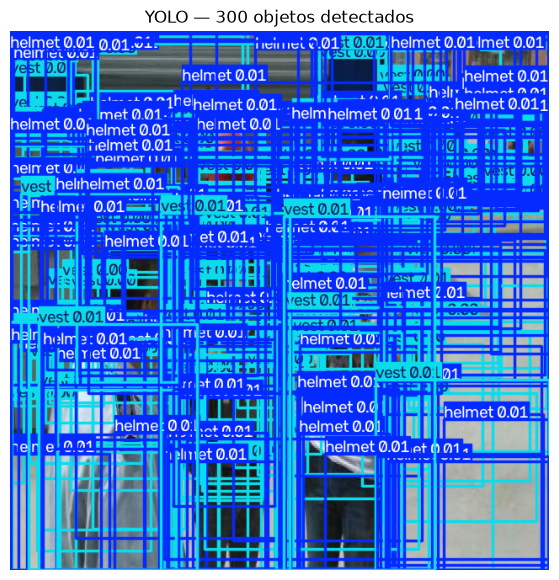

In [7]:
# r.plot() retorna la imagen anotada como array NumPy (BGR → convertir a RGB para matplotlib)
imagen_anotada = r.plot()
imagen_anotada_rgb = imagen_anotada[:, :, ::-1]  # BGR a RGB

plt.figure(figsize=(12, 7))
plt.imshow(imagen_anotada_rgb)
plt.title(f"YOLO — {len(r.boxes)} objetos detectados")
plt.axis("off")
plt.show()